```
<10-2_imbalanced_data.ipynb>

제미나이 의존도: 60-70%

f1-score도 추가하고, WeightRandomSampler도 손에 익힐 겸 한 번 더 연습해봤다.
f1-score(macro)는 데이터 불균형이 있는 상황에서 소수의 클래스를 틀리면 벌금을 심하게 때려서 점수가 잘 안나온다.
f1-score(macro)는 0.0이 가장 낮은 점수이고 1.0이 가장 높은 점수이다. 낮을수록 좋은 loss와는 반대이다.

Epoch 1/5 | Train Loss: 0.0882 | lr: 0.00009055
Val Acc: 97.95% | Macro F1: 0.9749
Epoch 2/5 | Train Loss: 0.0078 | lr: 0.00006580
Val Acc: 98.09% | Macro F1: 0.9766
Epoch 3/5 | Train Loss: 0.0034 | lr: 0.00003520
Val Acc: 97.10% | Macro F1: 0.9656
Epoch 4/5 | Train Loss: 0.0021 | lr: 0.00001045
Val Acc: 97.23% | Macro F1: 0.9672
Epoch 5/5 | Train Loss: 0.0010 | lr: 0.00000100
Val Acc: 97.89% | Macro F1: 0.9751
Test Acc: 98.04%

f1-score(macro)가 1.0에 가깝게 나왔고, 소수의 클래스도 잘 맞혔다는 것을 의미한다.

이번에는 오답노트도 작성해 보았다. 예측과 실제 정답이 틀린 이미지를 확인하는 작업이다.
물론 예전에도 이런 비슷한 일을 했지만, matplotlib 라이브러리로 하진 않았다.
그냥 틀린(preds != labels) 이미지 경로만 뽑아서 shutil() 함수로 새 디렉토리에 넣어서
배포된 FastAPI 서버에 일일이 태우는 방법을 했었다. 
틀린 이미지가 적으면 상관없지만, 많을 때는 이야기가 달라진다. 
만약 틀린 이미지가 100여 개라면 어느 세월에 배포된 모델에 일일이 태워서 예측값과 정답을 확인하겠는가?

matplotlib 라이브러리 다루는 게 익숙하지 않아서 힘들었지만, 제미나이 도움을 조금 받아서 코드 출력 셀에서 이미지를 띄웠다.

33개의 틀린 이미지를 한눈에 볼 수 있어서 가독성이 좋았다.
```

1. test 데이터셋 분리
2. val 데이터셋 분리
3. test, val 데이터셋이 빠진 상태에서 오렌지 100개 솎아내기

In [1]:
from glob import glob
import pandas as pd


path = "images/kaggle_data/dataset/*/*/*.png"

image_path_list = glob(path)
print(len(image_path_list))

# image_path_list.head(10)

label_map = {
    "apple/fresh_apple": 0, 
    "apple/rotten_apple": 1, 
    "banana/fresh_banana": 2, 
    "banana/rotten_banana": 3, 
    "orange/fresh_orange": 4, 
    "orange/rotten_orange": 5
}

data = []

for image_path in image_path_list:
    label = -1
    
    for keyword, label_value in label_map.items():
        if keyword in image_path:
            label = label_value
            break

    data.append({
        "image_path": image_path, 
        "label": label
    })

full_df = pd.DataFrame(data)

16831


In [2]:
from sklearn.model_selection import train_test_split

except_test_df, test_df = train_test_split(
    full_df, test_size=0.1, stratify=full_df['label'], random_state=42, shuffle=True
)
except_test_df = except_test_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

except_val_df, val_df = train_test_split(
    except_test_df, test_size=0.1, stratify=except_test_df['label'], random_state=42, shuffle=True
)
except_val_df = except_val_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

orange_df = except_val_df[except_val_df['label'].isin([4, 5])]
except_orange_df = except_val_df[~except_val_df['label'].isin([4, 5])]

sample_100_orange_df = orange_df.sample(n=100)

train_df = pd.concat([except_orange_df, sample_100_orange_df], ignore_index=True)

print(f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

print(f"Train Label Counts: {train_df['label'].value_counts().sort_index()}")
print(f"Val Label Counts: {val_df['label'].value_counts().sort_index()}")
print(f"Test Label Counts: {test_df['label'].value_counts().sort_index()}")

train_counts = train_df['label'].value_counts().rename('train')
val_counts = val_df['label'].value_counts().rename('val')
test_counts = test_df['label'].value_counts().rename('test')

summary_df = pd.concat([train_counts, val_counts, test_counts], axis=1).fillna(0).astype(int)
summary_df = summary_df.sort_index()
print(summary_df)

train: 10613, val: 1515, test: 1684
Train Label Counts: label
0    2283
1    3118
2    2308
3    2804
4      45
5      55
Name: count, dtype: int64
Val Label Counts: label
0    254
1    346
2    256
3    312
4    167
5    180
Name: count, dtype: int64
Test Label Counts: label
0    282
1    385
2    285
3    346
4    186
5    200
Name: count, dtype: int64
       train  val  test
label                  
0       2283  254   282
1       3118  346   385
2       2308  256   285
3       2804  312   346
4         45  167   186
5         55  180   200


In [18]:
# 데이터셋 구축
from torch.utils.data import Dataset, DataLoader
import cv2
import torch

class FruitsDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = row['image_path']
        image = cv2.imread(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            aug = self.transform(image=image)
            image = aug['image']

        label = int(row['label'])
        return image, torch.tensor(label, dtype=torch.long)

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(128, 128), 
    A.HorizontalFlip(p=0.5), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), 
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(128, 128), 
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), 
    ToTensorV2()
])

In [11]:
from torch.utils.data import WeightedRandomSampler

class_counts = train_df['label'].value_counts()
weights = 1.0 / class_counts
print(weights)

weights_dict = weights.to_dict()
print(weights_dict)

train_df['sample_weight'] = train_df['label'].map(weights_dict)
train_df.head()

sample_weights = train_df['sample_weight'].tolist()

sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

label
1    0.000321
3    0.000357
2    0.000433
0    0.000438
5    0.018182
4    0.022222
Name: count, dtype: float64
{1: 0.00032071840923669016, 3: 0.0003566333808844508, 2: 0.0004332755632582322, 0: 0.0004380201489268506, 5: 0.01818181818181818, 4: 0.022222222222222223}


In [19]:
BATCH_SIZE = 64
train_dataset = FruitsDataset(df=train_df, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)

val_dataset = FruitsDataset(df=val_df, transform=val_test_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = FruitsDataset(df=test_df, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels)

torch.Size([64, 3, 128, 128])
tensor([2, 2, 4, 5, 3, 4, 4, 1, 0, 5, 4, 1, 4, 4, 2, 0, 5, 1, 0, 4, 4, 5, 3, 3,
        4, 4, 4, 2, 0, 3, 2, 0, 5, 3, 5, 4, 0, 0, 0, 0, 1, 1, 3, 0, 1, 5, 2, 3,
        0, 4, 2, 0, 3, 0, 2, 2, 4, 0, 3, 2, 0, 2, 4, 0])


In [31]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models

EPOCHS = 5

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"device: {device}")

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 6)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

device: mps


In [32]:
from sklearn.metrics import f1_score
import numpy as np

# best_val_loss = float('inf')
best_macro_f1 = 0.0

for epoch in range(EPOCHS):
    # === Train Start ===
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_dataset):.4f} | lr: {lr:.8f}")
    
    # === Train End ===
    
    # === Val Start ===
    model.eval()
    val_count = 0
    # val_loss = 0.0

    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(1)
            val_count += (preds == labels).sum().item()

            # loss = criterion(outputs, labels)
            # val_loss += loss.item() * images.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    macro_f1 = f1_score(all_labels, all_preds, average="macro")
            
    # val_loss /= len(val_dataset)
    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     torch.save(model.state_dict(), "f1_imbalanced_data_weights.pth")

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        torch.save(model.state_dict(), "f1_imbalanced_data_weights.pth")
    
    
    print(f"Val Acc: {val_count/len(val_dataset) * 100:.2f}% | Macro F1: {macro_f1:.4f}")
            
    # === Val End ===
# === Test Start ===
best_model = models.resnet18(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, 6)
best_model.load_state_dict(torch.load("f1_imbalanced_data_weights.pth"))
best_model = best_model.to(device)
best_model.eval()

test_count = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = best_model(images)
        preds = outputs.argmax(1)
        test_count += (preds == labels).sum().item()

print(f"Test Acc: {test_count/len(test_dataset) * 100:.2f}%")
# === Test End ===

Epoch 1/5 | Train Loss: 0.0882 | lr: 0.00009055
Val Acc: 97.95% | Macro F1: 0.9749
Epoch 2/5 | Train Loss: 0.0078 | lr: 0.00006580
Val Acc: 98.09% | Macro F1: 0.9766
Epoch 3/5 | Train Loss: 0.0034 | lr: 0.00003520
Val Acc: 97.10% | Macro F1: 0.9656
Epoch 4/5 | Train Loss: 0.0021 | lr: 0.00001045
Val Acc: 97.23% | Macro F1: 0.9672
Epoch 5/5 | Train Loss: 0.0010 | lr: 0.00000100
Val Acc: 97.89% | Macro F1: 0.9751
Test Acc: 98.04%


33


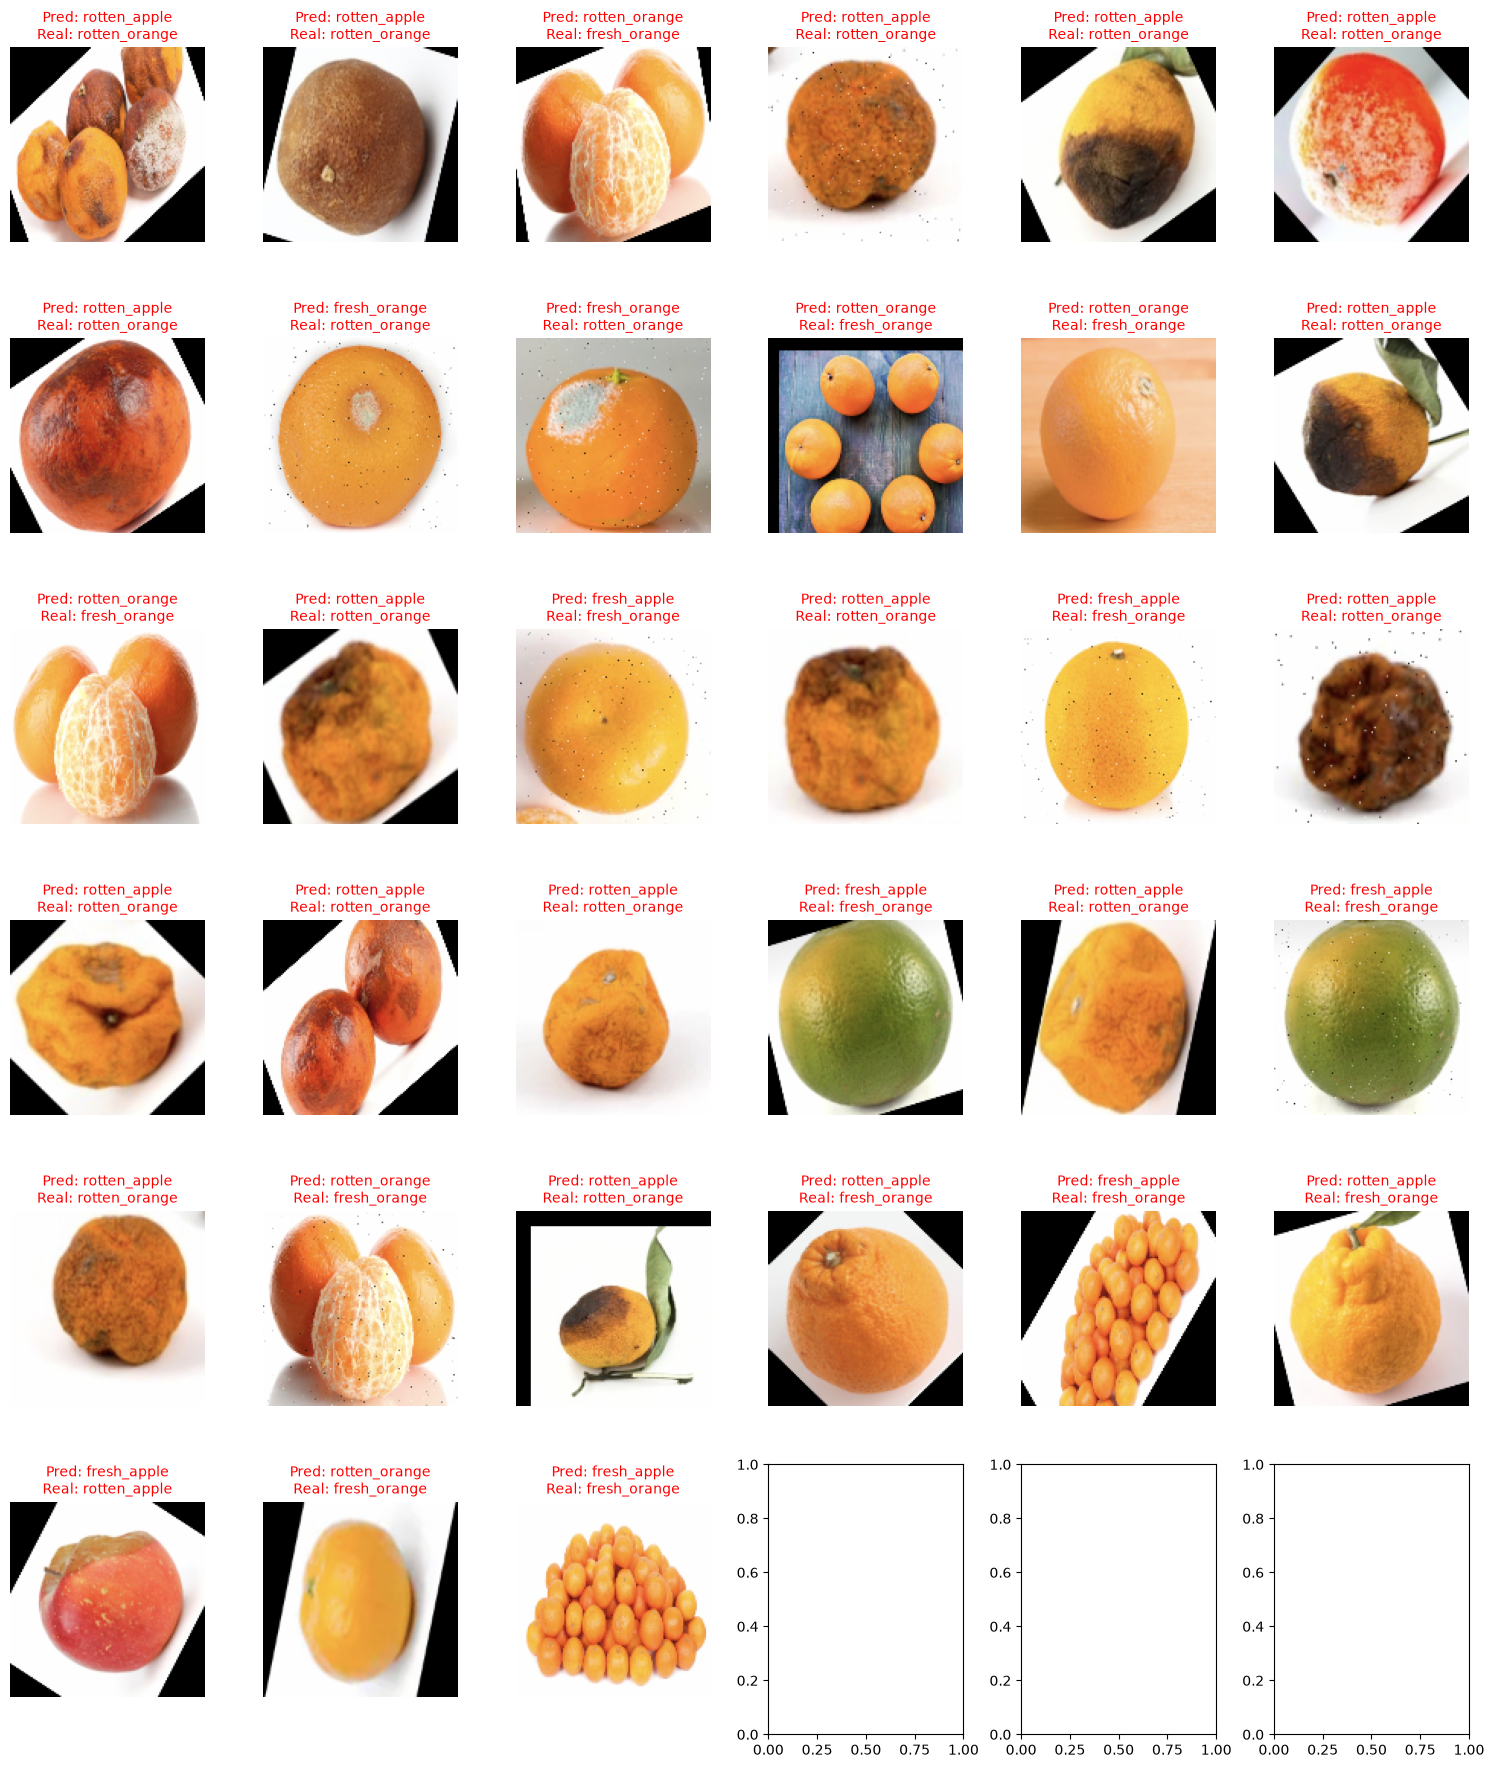

In [62]:
import matplotlib.pyplot as plt
from PIL import Image

# 틀린 것들만 목록을 만들어서 보여주자.
categories = [
    "fresh_apple", "rotten_apple", "fresh_banana", "rotten_banana", "fresh_orange", "rotten_orange"
]

new_test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

wrong_image_list = []
wrong_pred_list = []
wrong_label_list = []

best_model.eval()
with torch.no_grad():
    for images, labels in new_test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = best_model(images)
        preds = outputs.argmax(1)
        wrong_mask = (preds != labels)

        # 틀린 것들만 쏙쏙 골라낸 텐서 뭉치들
        wrong_images = images[wrong_mask]
        wrong_preds = preds[wrong_mask]
        wrong_labels = labels[wrong_mask]

        # 이번 배치에서 틀린 이미지의 개수만큼 반복문을 돕니다.
        for i in range(len(wrong_images)):
            # 1. 이미지는 낱장으로 꺼내서 리스트에 담습니다.
            wrong_image_list.append(wrong_images[i].cpu())

            # 2. 예측값 텐서에서 숫자 하나만 쏙 빼내서 담습니다.
            wrong_pred_list.append(wrong_preds[i].cpu().item())

            # 3. 실제 정답 텐서에서도 숫자 하나만 쏙 빼내서 담습니다.
            wrong_label_list.append(wrong_labels[i].cpu().item())

# wrong_images_all = torch.cat(wrong_images_all)

print(len(wrong_image_list))

# 격자 크기 계산하기
num_images = len(wrong_image_list)
num_cols = 6
num_rows = (num_images - 1) // num_cols + 1

# 액자판 만들기 (행이 많으니 세로 길이인 figsize의 두 번째 값을 넉넉히 18로 줍니다.)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 18))
axes = axes.flatten() # 2차원 배열 격자를 1차원으로 쭉 펼쳐서 편하게 인덱싱합니다.

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(num_images):
    pred = wrong_pred_list[i]
    real = wrong_label_list[i]

    img = wrong_image_list[i].permute(1, 2, 0).numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {categories[pred]}\nReal: {categories[real]}", color='red', fontsize=10)
    axes[i].axis('off')
    
    # plt.subplot(2, 4, i + 1)
    # plt.imshow(img)
    # plt.title(f"pred: {categories[pred]}\nreal: {categories[real]}")
    # plt.axis('off')

plt.tight_layout()
plt.show()


# print(wrong_images_all)

# print(wrong_mask)

# wrong_images = image

# images, labels = next(iter(new_test_loader))

# best_model.eval()
# with torch.no_grad():
#     outputs = model(images.to(device))
#     preds = outputs.argmax(1)

# plt.figure(figsize=(12, 8))

# mean = np.array([0.485, 0.456, 0.406])
# std = np.array([0.229, 0.224, 0.225])

# for i in range(8):
#     color = 'red'
#     if preds[i] == labels[i]:
#         color = 'blue'
#     elif preds[i] != labels[i]:
#         color = 'red'

#     img = images[i].permute(1, 2, 0).cpu().numpy()

#     img = (img * std) + mean

#     img = np.clip(img, 0, 1)

#     plt.subplot(2, 4, i + 1)
#     plt.imshow(img)
#     plt.title(f"pred: {categories[preds[i]]}\nlabel: {categories[labels[i]]}", color=color)
#     plt.axis('off')

# plt.tight_layout()
# plt.show()
